# Lineární regrese

## The Boston Housing Dataset

V minulém cvičení jsme zjistili, že výstupní proměnná MEDV je lineárně závislá na vstupních proměnných LSTAT a RM.

* RM - průměrný počet pokojů na byt (vstupní proměnná)
* LSTAT - procentuálně nižší stav populace (vstupní proměnná)
* MDEV - mediánová hodnota obydlí obývaných vlastníky v 1000 USD (výstupní proměnná)

## Cíl
Cílem tohoto cvičení je vytvoření lineárního modelu, který na základě vstupní hodnot RM (počet pokojů) a LSTAT (stav populace) odhadne MDEV (cena domů).

## Příprava dat

### Načtení dat

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

In [2]:
data = pd.read_csv ("..\\dataset\\HousingData.csv")

### Vyčištění dat

Odebrání záznamů s NULL hodnotami.

In [3]:
data=data.dropna()

Odebrání extrémních hodnot cen domů. Pro domy ve vyšší cenové hladině by výsledný lineární model nefungoval dobře (experimentálně ověřeno). Pro tyto domy by bylo vhodné vytvořit svůj vlastní model.

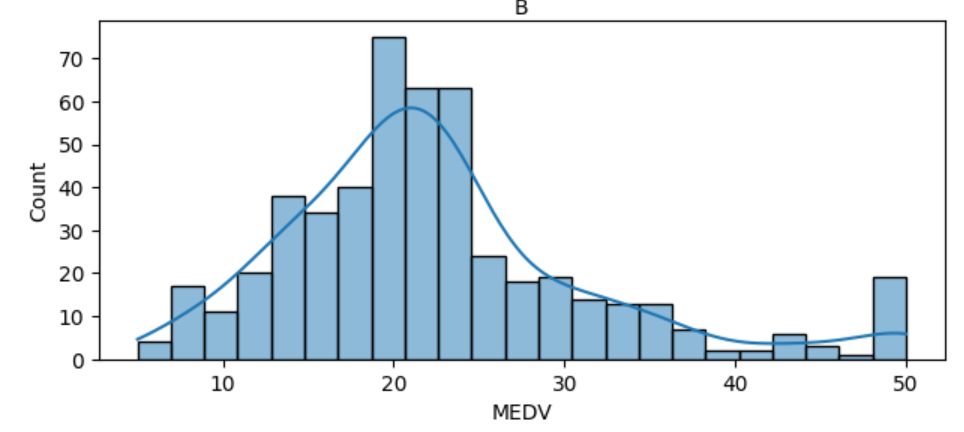

In [4]:
data = data[~(data['MEDV'] >= 40.0)]

## Lineární model s jednou proměnnou

Pro názornost nejprve vytvoříme model, který bude predikovat hodnotu MEDV z jedné vstupní proměnné RM

### Převedení hodnot z pandas na numpy pole

In [5]:
import numpy as np

Data rozdělíme na vstupní parametry X a výsledky Y.

In [6]:
X = pd.DataFrame(np.c_[data['RM']], columns = ['RM'])
y = data['MEDV']

In [7]:
X.describe()

,RM
count,371.000000
mean,6.189722
std,0.592102
min,3.561000
25%,5.870500
50%,6.164000
75%,6.512000
max,8.780000


In [8]:
y.describe()

count    371.000000
mean      20.818868
std        6.883723
min        5.000000
25%       16.400000
50%       20.600000
75%       24.250000
max       39.800000
Name: MEDV, dtype: float64

### Rozdělení souboru dat na trénovací, testovací a validační podmnožinu

Pro učení budeme používat knihovnu scikit-learn s algoritmy pro učení s a bez učitele.

Knihovnu si případně nainstalujete pomocí příkazu: **pip install scikit-learn**

In [9]:
from sklearn.model_selection import train_test_split

train_test_split rozděluje data set jen na 2 části.

Vytvoříme si funkci, která data rozdělí na 3 části - trénovací, validační a testovací dat

In [10]:
def split_dataset (X, y, train_ratio = 0.75, validation_ratio = 0.15, test_ratio = 0.10):
    """ Rozdělení datového souboru na subsety pro trénování, validaci a testování
        X - vysvětlující proměnné
        y - vysvětlená proměnná

        train_ratio      - poměr trénovacích dat
        validation_ratio - poměr validačních dat
        test_ratio       - poměr testovacích dat

    """
    assert(train_ratio + validation_ratio + test_ratio == 1.0)

    # train nyní tvoří 75 % celého souboru dat
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio)

    # test je nyní 10 % původního souboru dat
    # nyní představuje 15 % původního souboru dat
    X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio)) 
    return X_train, y_train, X_val, y_val, X_test, y_test

Dataset rozdělíme a zkontrolujeme si velikost jednotlivých částí.

In [11]:
X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(X, y)
print (X_train.shape, y_train.shape)
print (X_val.shape, y_val.shape)
print (X_test.shape, y_test.shape)

(278, 1) (278,)
(55, 1) (55,)
(38, 1) (38,)


### Ruční lineární regrese
Než si ukážeme funkci z knihovny scikit-learn, které lineární model vytvoří během okamžiku, zkusíme si model vytvořit ručně a odladit jednotlivé kroky.

To vám umožní pochopit princip učení většiny modelů umělé inteligence.

Na začátku procesu učení je potřeba parametry inicializovat náhodnými hodnotami.

In [12]:
import random
def initialize(dim):
    """ Počáteční nastavení parametrů lineárního modelu – bias a weights
    """
    bias=random.random()
    weights=np.random.rand(dim)
    return bias, weights

In [13]:
def print_model_params(bias, weights):
    """Zobrazení aktuálních parametrů modelu
    """
    print ("Model parameters\n================")
    print(f"Bias: {bias}")
    print (f"Weights: {weights}")  

In [14]:
bias, weights=initialize(X.shape[1])
print_model_params(bias, weights)

Model parameters
Bias: 0.5542499706346133
Weights: [0.36390918]


Vytvoříme si funkci, která pro vstupní hodnoty X a parametry modelu predikuje výstupní hodnotu y.

Pro zrychlení se používá funkce násobení matic z knihovny numpy.

In [15]:
def predict(X, bias, weights):
    """ Na základě parametrů modelu (bias a weights) funkce vypočítá výstupní hodnotu y ze vstupních hodnot X.
        X - vstupní matice numpy
        bias - model parameter b
        weights - pole weights

        Vrací matici predikovaných hodnot y.
    """
    return bias + np.dot(X, weights)

Vyzkoušíme si, jak s model s náhodnými parametry predikuje výstupní hodnoty pro trénovací data.

In [16]:
print ("Predicted values\n================")
y_predicted = predict(X_train, bias, weights)
y_predicted[0:10]

Predicted values


array([3.10416163, 3.13036309, 3.09251653, 3.01063697, 2.53973848,
       2.38689662, 2.78392154, 2.73151862, 2.92548222, 2.69258034])

Trénovací data a lineární model si vyneseme do stejného grafu. 

In [17]:
def visualize_model_2d (X, y, y_predicted):
    """ Vizualizace jednoduchého lineárního modelu ve 2D
        X - skutečná vstupní data
        y - skutečná výstupní data
        y_predicted - předpokládané výstupní data
    """
    plt.figure() 
    plt.plot (X, y_predicted, c='b', label = "Train prediction")
    plt.scatter (X, y, marker = 'x', c='r', label="Train actual")
    plt.title ("Model")
    plt.ylabel("$")
    plt.xlabel("RM")
    plt.legend()
    plt.show()

Pro náhodné parametry model příliš nedokáže predikovat hodnoty.

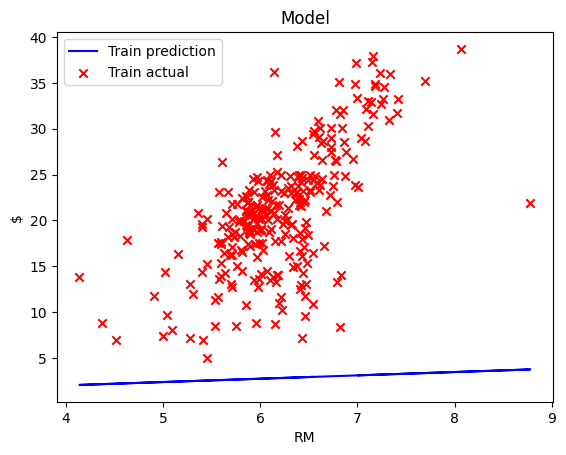

In [18]:
visualize_model_2d(X_train, y_train, y_predicted)

### Nákladová funkce

Jak moc se predikce modelu liší od skutečných hodnot říká nákladová funkce. Nákladových funkcí je více, pro lineární regresi budeme používat MSE (Mean square error).

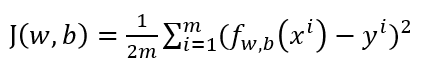

In [19]:
def get_cost(y, y_predicted):
    """ Vrátit MSE pro skutečná a předpovězená výstupní data
    """
    y_resd = y - y_predicted
    return np.sum(np.dot(y_resd.T, y_resd))/(len(y - y_resd)*2)

In [20]:
def print_cost (y_train, y_predicted):
    print (f"Cost function MSE: {get_cost(y_train, y_predicted)}")

Model s náhodnými parametry bude mít hodnotu nákladové funkce hodně vysokou.

In [21]:
print_cost(y_train, y_predicted)

Cost function MSE: 187.36762994435742


### Hodnocení modelu
Pro hodnocení modelu použijeme: 
- R2 funkce (R-squared, coefficient of determination, regression score function). Hodnota pro model, který bezchybně předvídá data je 1.0. Větší hodnota je lepší.
- RMSE (root mean square error). Menší hodnota je lepší

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

In [23]:
def print_model_score(y_train, y_predicted):
    """ Zobrazení modelu skóre
    """
    r2 = r2_score(y_train, y_predicted)
    rmse = (np.sqrt(mean_squared_error(y_train, y_predicted)))    
    print('R2 score: {}'.format(r2))    
    print('RMSE: {}'.format(rmse))

In [24]:
print_model_score (y_train, y_predicted)

R2 score: -7.4027877409699965
RMSE: 19.358079963899183


### Jedna iterace učení
Parametry modelu máme nastavené na náhodné hodnoty. V této sekci provedeme jednu iteraci učení. 

Po jejím dokončení by skóre modelu mělo být lepší.

Pro zlepšení parametrů modelu je třeba vypočítat parciální derivaci, které nám určí směr posunu parametru. Velikost změny parametru se koriguje přes learning rate. Detaily jsou vysvětleny v přednášce.

In [25]:
def update_weights(X, y, y_predicted, bias_0, weights_0, learning_rate):
    """ Funkce upravuje parametry modelu, jako jsou bias a weights.

        X - vstupní data
        y - správná výstupní data
        y_predicted - předvídaná výstupní data
        bias_0 - aktuální hodnota bias
        weights_0 - aktuální hodnoty weights
        learning_rate - learning rate alpha

    """

    # výpočet parciálních derivací
    delta_bias = (np.sum(y_predicted - y))/len(y)
    delta_weights = (np.dot((y_predicted - y),X))/len(y)

    # výpočet úprav parametrů modelu
    bias_1 = bias_0 - learning_rate * delta_bias
    weights_1 = weights_0 - learning_rate * delta_weights
    return bias_1, weights_1

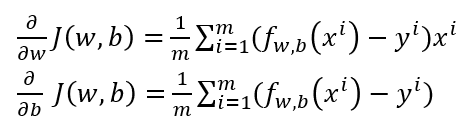

In [26]:
y_predicted = predict(X_train, bias, weights)
bias, weights = update_weights(X_train, y_train, y_predicted, bias, weights, 0.01)
print_model_params(bias, weights)

Model parameters
Bias: 0.7364421075966823
Weights: [1.51754316]


Hodnotu nákladové funkce, graf a skóre porovnejte s předchozími.

In [27]:
y_predicted = predict(X_train, bias, weights)
print_cost(y_train, y_predicted)

Cost function MSE: 78.07507746935377


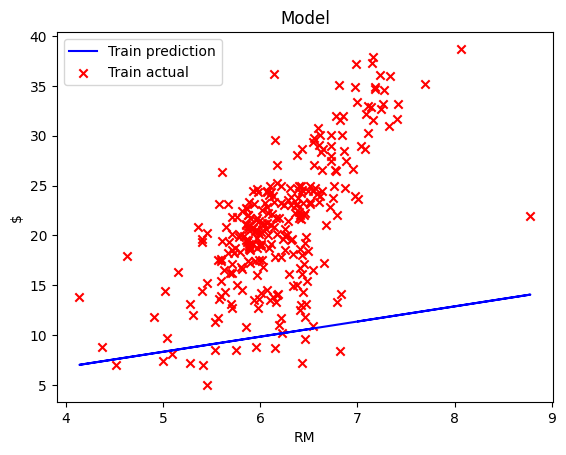

In [28]:
visualize_model_2d(X_train, y_train, y_predicted)

In [29]:
print_model_score (y_train, y_predicted)

R2 score: -2.5013961804907026
RMSE: 12.49600555932605


### Celé učení
V předchozí sekci jsme si ukázali pouze jednu iteraci učení. Nyni si vytvoříme funkci, která v cyklu bude provádět jednotlivé iterace.

In [30]:
def run_gradient_descent(X, y, learning_rate, num_iterations):
    """ Algoritmus gradient descent 
        X - vstupní data
        Y - výstupní data
        learning_rate - learning rate alpha
        num_iteration - počet iterací

        gd_iterations_df - historie učení
        bias             - bias parametr
        weights          - weights parametr
    """
    # inicializace parametrů modelu
    bias, weights=initialize(X.shape[1])
    iter_num=0

    # uložení průběhu učení do datového rámce
    gd_iterations_df=pd.DataFrame(columns=['iteration','cost'])
    result_idx=0
    
    for each_iter in range(num_iterations):
        # zobrazení kontrolního skóre
        y_predicted = predict(X, bias, weights)
        this_cost=get_cost(y, y_predicted)

        # zlepšení parametrů
        prev_bias=bias
        prev_weights=weights
        bias, weights = update_weights(X, y, y_predicted, prev_bias, prev_weights, learning_rate)

        # ukládání každé desáté iterace do historie učení
        if(iter_num % 10==0):
            gd_iterations_df.loc[result_idx]=[iter_num, this_cost]
            result_idx=result_idx+1

        iter_num +=1    
    return gd_iterations_df, bias, weights

In [31]:
gd_iterations_df, bias, weights=run_gradient_descent(X_train, y_train, learning_rate=0.001, num_iterations=200)

Zobrazíme se výsledný model a můžeme ho porovnat s první iterací.

In [32]:
print_model_params(bias, weights)
y_predicted=predict(X_train, bias, weights)
print_cost(y_train, y_predicted)
print_model_score (y_train, y_predicted)

Model parameters
Bias: 0.37838373554080407
Weights: [3.36648304]
Cost function MSE: 15.659999189263718
R2 score: 0.2977034013280587
RMSE: 5.596427286986532


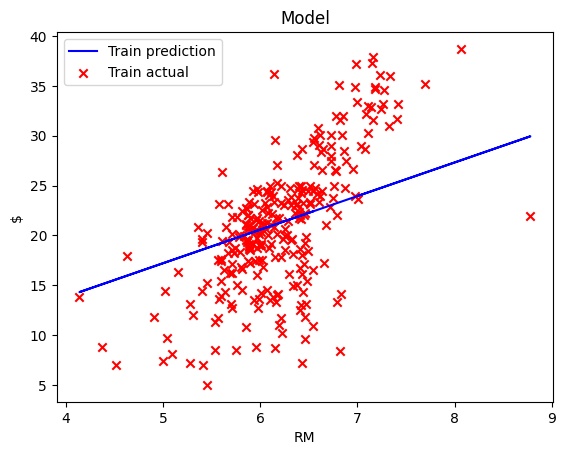

In [33]:
visualize_model_2d(X_train, y_train, y_predicted)

### Validace modelu
Během procesu učení jsme upravovali parametry modelu, tak aby co nejvíce odpovídal (fitoval) trénovacím datům.

Nyní je třeba ověřit, jestli model bude správně fungovat i na datech, která ještě neviděl (X_val).

In [34]:
y_val_predicted = predict(X_val, bias, weights)
print_cost(y_val, y_val_predicted)
print_model_score(y_val, y_val_predicted)

Cost function MSE: 25.871950574118625
R2 score: 0.12648680575761595
RMSE: 7.193323372978393


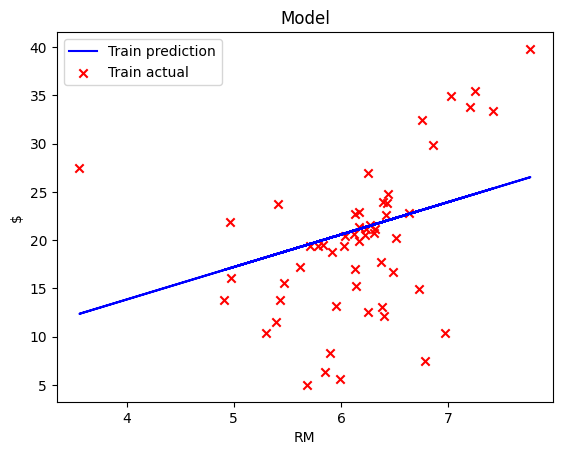

In [35]:
visualize_model_2d(X_val, y_val, y_val_predicted)

### Proces učení
Jestli proces učení probíhal v pořádku, můžeme zjistit z grafu, který nám ukazuje vývoj nákladové funkce v průběhů iterací.

Pokud proces učení funguje správně, nákladová funkce by měla klesat.

Text(0, 0.5, 'Cost or MSE')

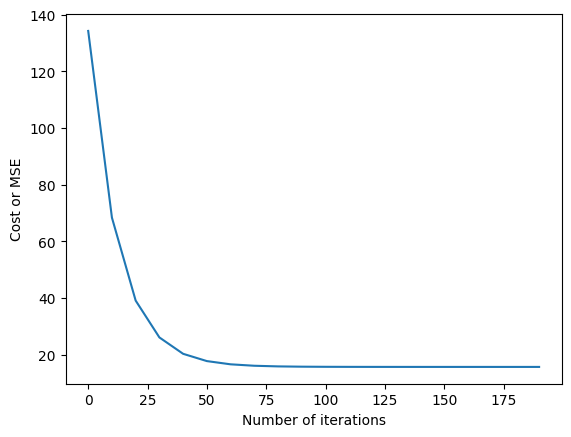

In [36]:
plt.plot(gd_iterations_df['iteration'], gd_iterations_df['cost'])
plt.xlabel("Number of iterations")
plt.ylabel("Cost or MSE")

### Rychlost učení
Rychlost učení je dána hodnotou learning_rate. Tedy číslem, které určuje velikost změn parametrů modelu.

S vyšším learning rate se model bude učit rychleji, ale je zde riziko, že proces učení nebude fungovat. (viz přednáška)

Vliv learning rate si ukážeme na dvou grafech historie učení. 

In [37]:
alpha_df_1, bias_1, weights_1=run_gradient_descent(X_train, y_train, learning_rate=0.01, num_iterations=200)
alpha_df_2, bias_2, weights_2=run_gradient_descent(X_train, y_train, learning_rate=0.001, num_iterations=200)

Výsledné modely jsou téměř totožné.

Model parameters
Bias: 0.6008736853684581
Weights: [3.33163333]
Cost function MSE: 15.71123724556915


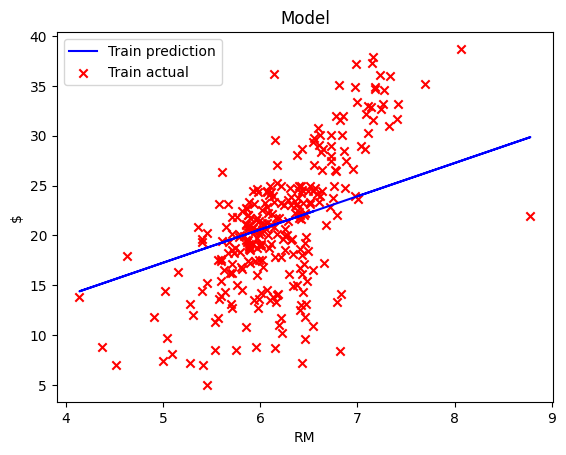

In [38]:
print_model_params(bias_1, weights_1)
Y_predicted_1 = predict(X_train, bias_1, weights_1)
print_cost(y_train, Y_predicted_1)
visualize_model_2d(X_train, y_train, Y_predicted_1)

Model parameters
Bias: 0.7890336769366643
Weights: [3.30082397]
Cost function MSE: 15.754965334889237


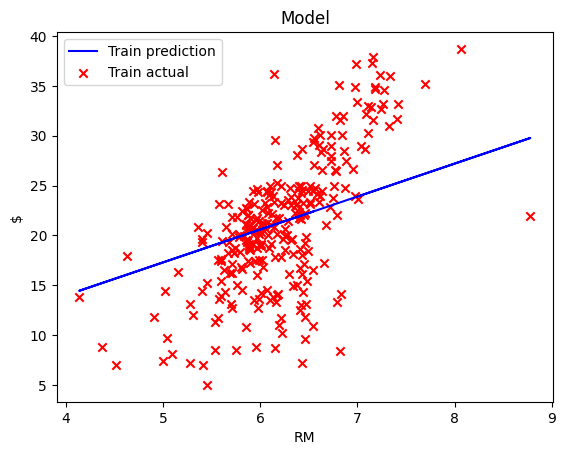

In [39]:
print_model_params(bias_2, weights_2)
Y_predicted_2 = predict(X_train, bias_2, weights_2)
print_cost(y_train, Y_predicted_2)
visualize_model_2d(X_train, y_train, Y_predicted_2)

Při vyšším learning rate hodnota nákladové funkce klesá rychleji.

Text(0.5, 1.0, 'Cost vs. Iterations for different alpha values')

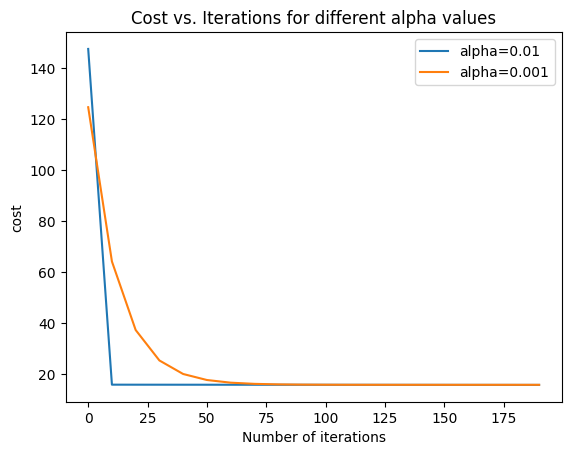

In [40]:
# rychlost trénování modelu pro různé hodnoty alfa učení
plt.plot(alpha_df_1['iteration'],alpha_df_1['cost'],label="alpha=0.01")
plt.plot(alpha_df_2['iteration'],alpha_df_2['cost'],label="alpha=0.001")
plt.legend()
plt.ylabel('cost')
plt.xlabel('Number of iterations')
plt.title('Cost vs. Iterations for different alpha values')

## Lineární model s více proměnnými

Nyní si vytvoříme model se dvěma parametry RM a LSTAT.

### Příprava data

In [41]:
X = pd.DataFrame(np.c_[data['RM'],data['LSTAT']], columns = ['RM', 'LSTAT']).to_numpy()
y = data['MEDV'].to_numpy()

Kontrola velikosti subdatasetů

In [42]:
X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(X, y)
print(X_train.shape, y_train.shape)
print (X_val.shape, y_val.shape)
print (X_test.shape, y_test.shape)

(278, 2) (278,)
(55, 2) (55,)
(38, 2) (38,)


Jeden záznam z trénovacích dat.

In [43]:
print (X_train[0, :])
print (y_train[0])

[6.511 5.28 ]
25.0


### Vizualizace dat ve 3D
Protože máme dvě vstupní proměnné a jednu výstupní. Data nejlépe zobrazíme ve 3D grafu.

In [44]:
x_label, y_label, z_label = "RM", "LSTAT", "MEDV"
x1 = X_train[:, 0]  # 1. sloupec
x2 = X_train[:, 1]  # 2. sloupec
y = y_train  # Cílová proměnná
    
# 3D graf
fig = go.Figure(layout=go.Layout(width=1000, height=1000))

fig.add_trace(go.Scatter3d(
        x=x1, y=x2, z=y,
        mode='markers',
        marker=dict(size=5, color=y, colorscale='Viridis', opacity=0.8),
        name="Data"
))
fig.show()

### Inicializace modelu
Inicializujeme parametry a pak spustíme první iteraci.

Protože potřebné funkce jsme napsali pomocí numpy polí, můžeme je použít v nezměněné podobě.

Zobrazíme si parametry modelu, predikované hodnoty, hodnotu nákladové funkce a hodnocení modelu.

In [45]:
bias, weights=initialize(X.shape[1])
print_model_params(bias, weights)

Model parameters
Bias: 0.08519154033889331
Weights: [0.75683159 0.2624967 ]


In [46]:
y_predicted=predict(X_train, bias, weights)
y_predicted[0:10]

array([ 6.39890462,  8.09111774,  7.03766219,  9.19769516,  6.97224936,
       12.38119612, 10.57208475,  7.72004955,  6.8783252 ,  7.63475658])

In [47]:
print_cost(y_train, y_predicted)

Cost function MSE: 115.15819934553376


In [48]:
# počáteční skóre modelu
print_model_score (y_train, y_predicted)

R2 score: -3.966494527377783
RMSE: 15.176178659038893


Protože máme dva vstupní proměnné, tak výsledný lineární model bude mít tvar roviny v prostoru.

Pro jeho zobrazení tedy použijeme 3D graf.

In [49]:
def visualize_model_3D(x1, x2, y, bias, weights, points=50):      
    # Descriptions of axis
    x_label, y_label, z_label = "RM", "LSTAT", "MEDV"
    
    # Creating a 3D scatter plot
    fig = go.Figure(layout=go.Layout(width=1000, height=1000))

    # Scatter plot - data
    fig.add_trace(go.Scatter3d(
        x=x1, y=x2, z=y,
        mode='markers',
        marker=dict(size=5, color=y, colorscale='Viridis', opacity=0.8),
        name="Data"
    ))

    # Model curve
    x_range = np.linspace(min(x1), max(x1), points)
    y_range = np.linspace(min(x2), max(x2), points)
    xs, ys = np.meshgrid(x_range, y_range)
    zs = xs * weights[0] + ys * weights[1] + bias 

    fig.add_trace(go.Surface(
        x=xs, y=ys, z=zs,
        colorscale="Blues",
        opacity=0.5,
        name="Model Surface"
    ))

    fig.update_layout(
        title="3D Model Visualization",
        scene=dict(
            xaxis_title=x_label,
            yaxis_title=y_label,
            zaxis_title=z_label
        )
    )

    # Zobrazení grafu
    fig.show()

In [50]:
visualize_model_3D (x1, x2, y_train, bias, weights, 30)

## První iterace iterace

In [51]:
bias, weights = update_weights(X_train, y_train, y_predicted, bias, weights, 0.01)

In [52]:
print_model_params(bias, weights)

Model parameters
Bias: 0.21414449084875503
Weights: [1.58572282 1.46095522]


In [53]:
Y_predicted=predict(X_train, bias, weights, )
print_cost(y_train, Y_predicted)
print_model_score (y_train, Y_predicted)

Cost function MSE: 148.42082001165554
R2 score: -5.401030882091495
RMSE: 17.22909283808382


In [54]:
visualize_model_3D (x1, x2, y_train, bias, weights, 30)

### Celé učení

In [55]:
gd_iterations_df, bias, weights=run_gradient_descent(X_train, y_train, learning_rate=0.001, num_iterations=500)

In [56]:
print_model_params(bias, weights)

Model parameters
Bias: 0.6127244159608052
Weights: [ 4.32363963 -0.50003267]


In [57]:
Y_predicted=predict(X_train, bias, weights)
print_cost(y_train, Y_predicted)
print_model_score (y_train, Y_predicted)

Cost function MSE: 9.107449012544903
R2 score: 0.6072177583859495
RMSE: 4.267891519836206


In [58]:
visualize_model_3D(x1, x2, y_train, bias, weights, 40)

### Validace modelu

In [59]:
Y_val_predicted = predict(X_val, bias, weights, )
print_cost(y_val, Y_val_predicted)
print_model_score (y_val, Y_val_predicted)

Cost function MSE: 8.056598296201637
R2 score: 0.6603792826595238
RMSE: 4.014124635883055


### Proces učení

Text(0, 0.5, 'Cost or MSE')

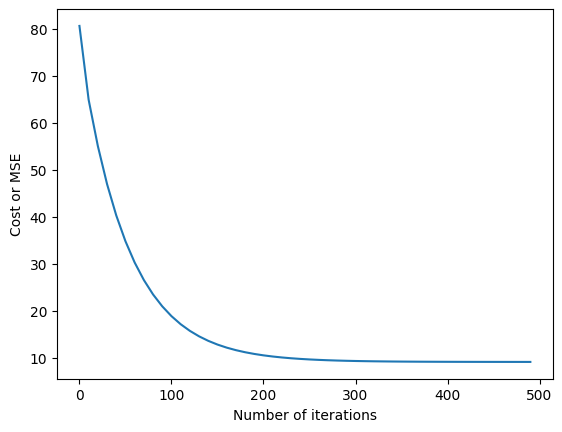

In [60]:
fig2=plt.figure()
plt.plot(gd_iterations_df['iteration'], gd_iterations_df['cost'])
plt.xlabel("Number of iterations")
plt.ylabel("Cost or MSE")

## Lineární model z scikit-sklearn
Doposud jsme celé učení programovali ručně. Bylo to z důvodu, abychom si ukázali postupný proces učení.

Samozřejmě na vytváření lineárního a dalších modelů existují knihovny. Například scikit-sklearn.

Stejnou úlohu si teď ukážeme s použitím této knihovny.

### Vytrénování modelu

In [61]:
from sklearn.linear_model import LinearRegression

Vytvoření linearního modelu

In [62]:
lin_model = LinearRegression()

Trénování modelu na tréninkových datech. Data fitujeme na model.

In [63]:
lin_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Vypsání parametrů modelu

In [64]:
print ("Bias: ", lin_model.intercept_)
print("Weights: ", lin_model.coef_)

Bias:  12.613457384469058
Weights:  [ 2.64440192 -0.61555849]


Predikce výstupních hodnot z trénovacích dat

In [65]:
y_predicted = lin_model.predict(X_train)

Zobrazení skóre a modelu

In [66]:
print_model_score(y_train, Y_predicted)

R2 score: 0.6072177583859495
RMSE: 4.267891519836206


In [67]:
visualize_model_3D(x1, x2, y_train, lin_model.intercept_, lin_model.coef_, 40)

### Ověření modelu
Model vyzkoušíme na validačních datech.

In [68]:
y_val_predict = lin_model.predict(X_val)

In [69]:
print_model_score(y_val, y_val_predict)

R2 score: 0.6896856527470996
RMSE: 3.837025568402236


### Uložení modelu do souboru
Vytrénovaný model si můžeme uložit pro pozdější použití. 

Například napíšeme webovou aplikaci, kam uživatele zadá počet pokojů a stav populace a model mu vrátí odhad ceny bytu.

Je nutné si uvědomit, že model bude platný pouze pro Boston v roce 1978.

In [70]:
import pickle
filename = 'regression_linear_model.sav'
pickle.dump(lin_model, open(filename, 'wb'))

V programu bychom model načetli pomocí následujícího příkladu.

In [71]:
loaded_model = pickle.load(open(filename, 'rb'))

A použili bychom ho. Vstupní hodnoty uložíme do pole a pak spustíme funkci predict.

In [72]:
x=[[5.87, 14.37]]
y_predicted = loaded_model.predict(x)
print (f"The estimated price of the property is {y_predicted[0]}")

The estimated price of the property is 19.290521191115012
